<a href="https://colab.research.google.com/github/KrisDA-1/ML.Fraud_Detection/blob/main/ML_FinalAssessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK1. Data analysis and opportunity identification



##Data preprocessing

###We prepare the environment with libraries like pandas, numpy, scikit learn, matplotlib and seaborn for data manipulation, numerical operations, visualisation and scaling.
###Understand dataset size, data types and identify any incomplete

In [14]:
##Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [16]:
##Read the excel file and display the first rows of the DataFrame
df=pd.read_excel('creditcard.xlsx')
print(df.head()) ##Using print is important so we ensure the original dataset is used without problem


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [17]:
##Checking the shape of the df
df.shape

(284807, 31)

In [18]:
##Checking the data types and missing values
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
##Checking columns in the data
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
##Checking the count of unique categories in all object type columns
for column in df.select_dtypes(include='object').columns:
  print("Column:", column)
  print("Unique Categories:", df[column].nunique())
  print(" ")

###>>>Missing Values

In [ ]:
##Percentage of missing values per column
print(df.isnull().mean()*100)

Time      0.000000
V1        0.000000
V2        0.000000
V3        0.000000
V4        0.000000
V5        0.000000
V6        0.000000
V7        0.000000
V8        0.000000
V9        0.000000
V10       0.000000
V11       0.000000
V12       0.000000
V13       0.002453
V14       0.002453
V15       0.002453
V16       0.002453
V17       0.002453
V18       0.002453
V19       0.002453
V20       0.002453
V21       0.002453
V22       0.002453
V23       0.002453
V24       0.002453
V25       0.002453
V26       0.002453
V27       0.002453
V28       0.002453
Amount    0.002453
Class     0.002453
dtype: float64


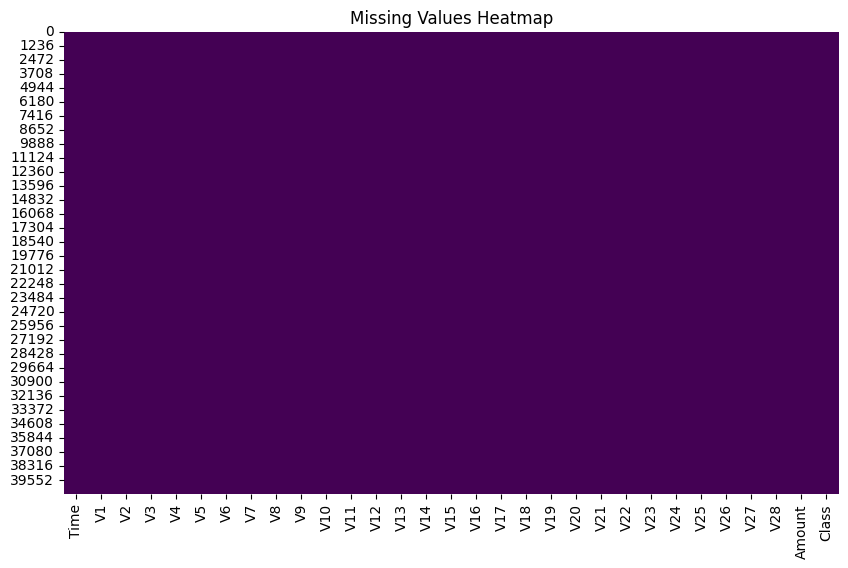

In [ ]:
##Visualise Missingness using a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

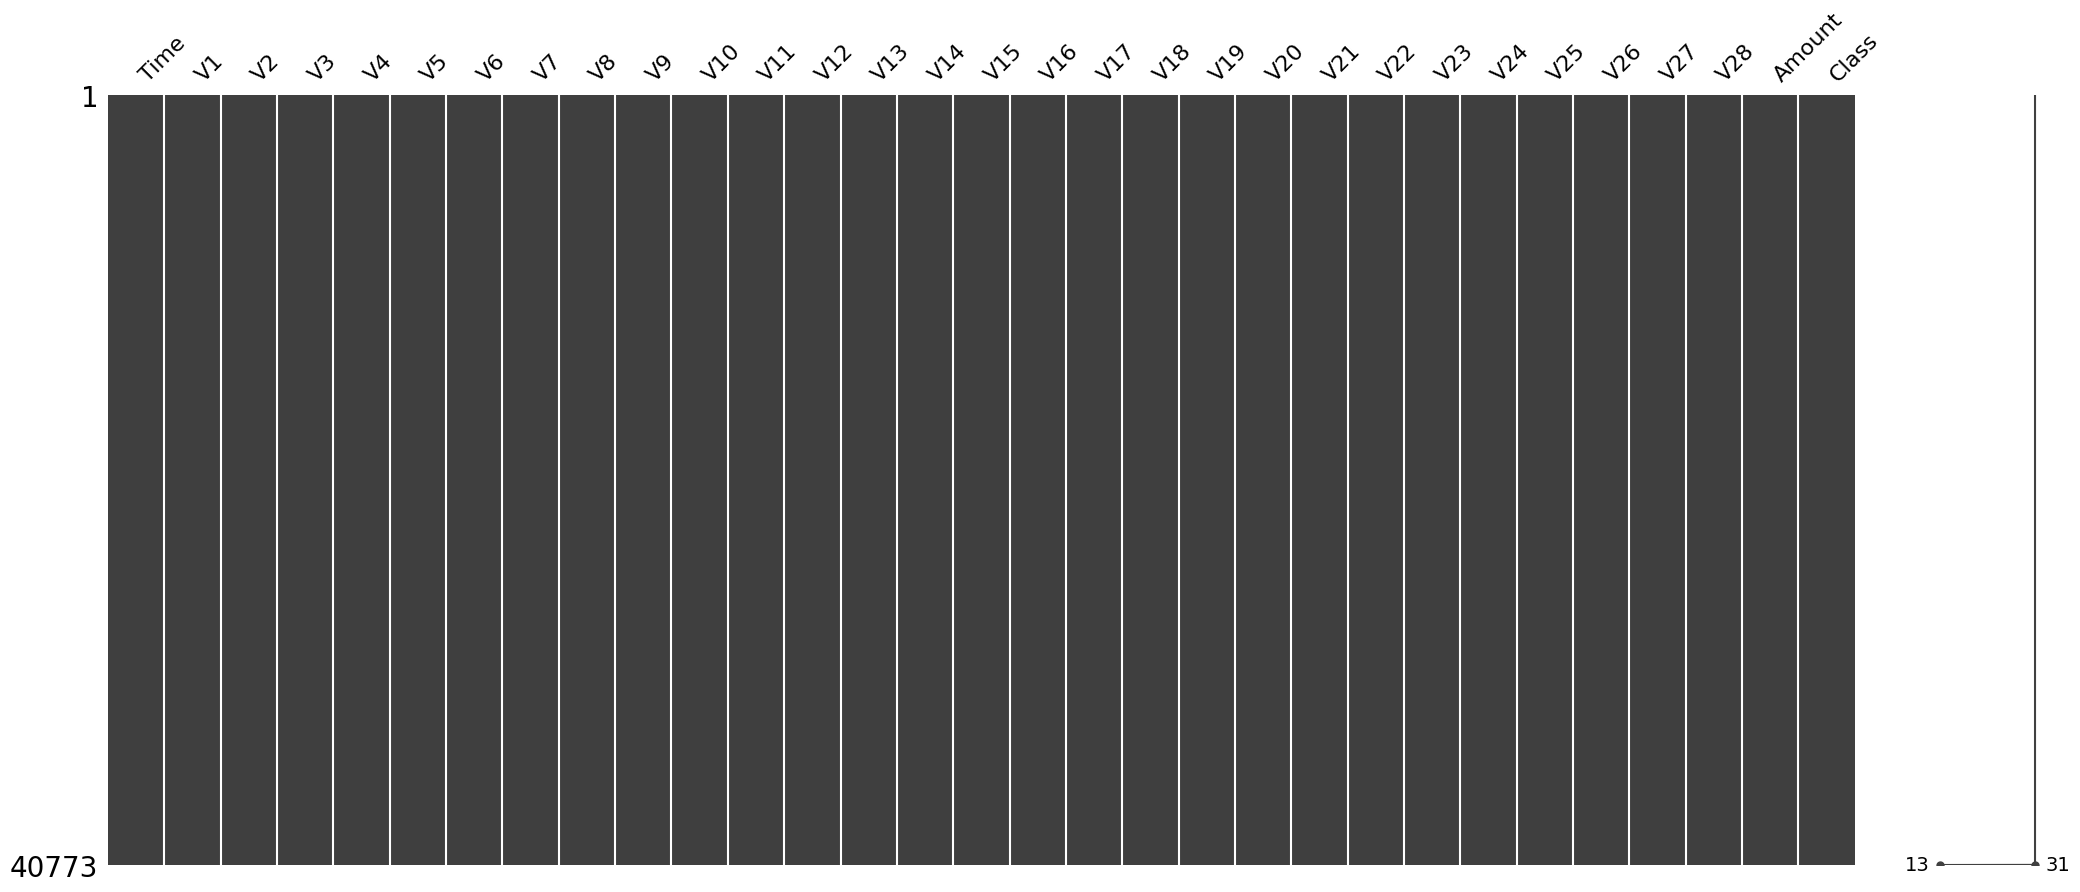

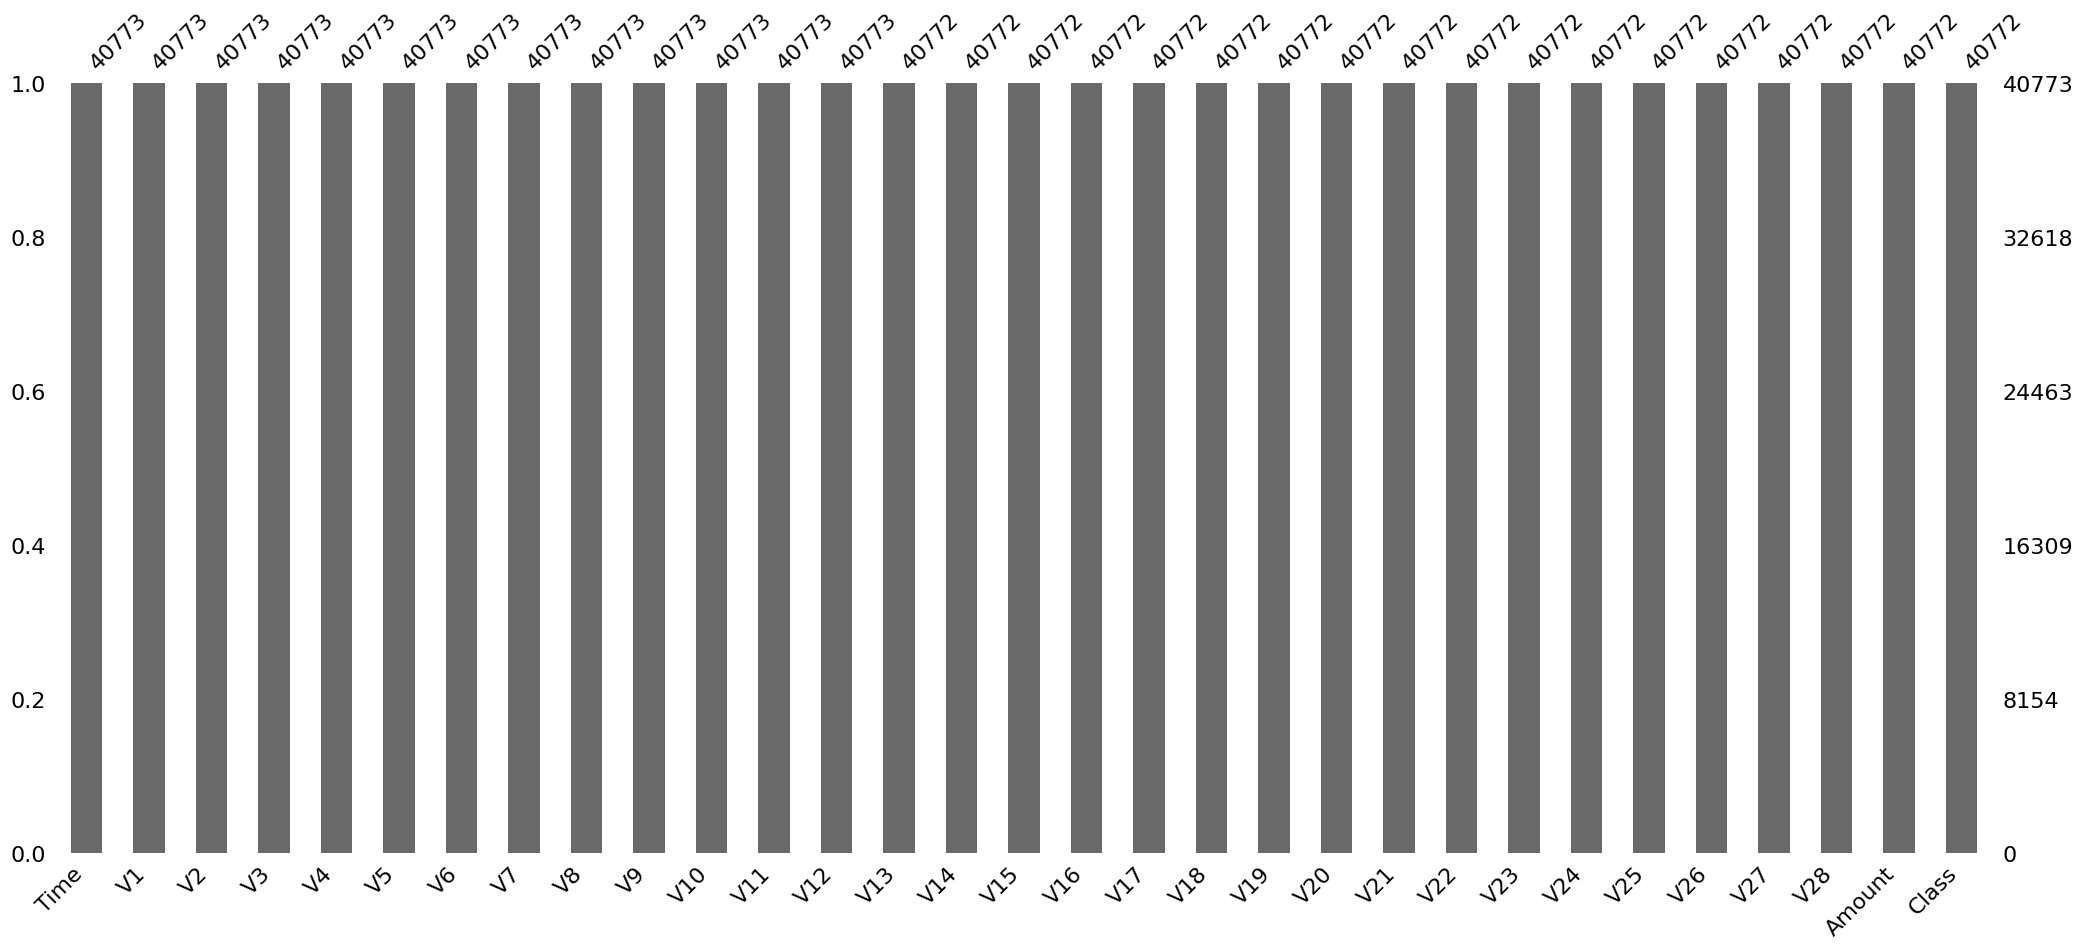

In [ ]:
##Visual Toolkit for Missing
#### Highlitghts which rows have missing data

!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt

###Shows completeness of each row - Matrix plot
#### shows missing count/percentage per column
msno.matrix(df)
plt.show()

###Missing couunt per column - Bar plot
#### Shows relationships, if column A missing often implies B missing
msno.bar(df)
plt.show()



In [ ]:
##See only rows containing missing values
missing_rows=df[df.isnull().any(axis=1)]
print(missing_rows)

        Time        V1        V2        V3        V4        V5        V6  \
40772  40393  1.087233 -0.919047  0.097149  0.185226 -0.404768  0.986686   

             V7       V8        V9  ...  V21  V22  V23  V24  V25  V26  V27  \
40772 -0.612788  0.12625 -0.750372  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

       V28  Amount  Class  
40772  NaN     NaN    NaN  

[1 rows x 31 columns]


In [ ]:
##Delete missing values by keeping original DataFrame intact
df_new = df.drop(df.index[40772])

In [ ]:
##Checking the shape of the df_new to confirm row was deleted successfully
df_new.shape

(40772, 31)

###>>>Statistical summary, handling and visualisation outliers

#####From now on will be using df_new

In [ ]:
##Statistical summary for numeric and non-numeric columns
df_new.describe(include='all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,...,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000,40772.000000
mean,25886.967968,-0.218959,0.040780,0.712371,0.187867,-0.232721,0.100305,-0.112555,0.043497,0.203231,...,-0.028868,-0.111939,-0.040506,0.007718,0.135958,0.023531,0.008017,0.005081,88.613110,0.002600
std,12677.811316,1.853491,1.598598,1.497921,1.400283,1.388746,1.311450,1.242995,1.215371,1.222613,...,0.746955,0.638048,0.558527,0.592842,0.436744,0.504642,0.386791,0.342590,237.094596,0.050923
min,0.000000,-56.407510,-72.715728,-31.103685,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.438650,-8.567638,-9.617915,0.000000,0.000000
25%,15748.000000,-0.969765,-0.529432,0.231038,-0.719252,-0.840250,-0.638457,-0.598419,-0.151961,-0.562255,...,-0.235825,-0.534392,-0.178860,-0.324803,-0.128163,-0.330127,-0.063249,-0.006881,7.447500,0.000000
50%,31003.500000,-0.236000,0.096933,0.813741,0.186208,-0.269921,-0.157277,-0.073597,0.049496,0.080975,...,-0.075735,-0.086682,-0.051455,0.060861,0.176005,-0.063733,0.008435,0.021580,23.900000,0.000000
75%,35990.250000,1.159943,0.740709,1.445227,1.070129,0.294637,0.487875,0.432750,0.317491,0.919089,...,0.101812,0.299981,0.077075,0.399918,0.421090,0.305511,0.084915,0.076201,79.950000,0.000000
max,40393.000000,1.960497,16.713389,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,7879.420000,1.000000


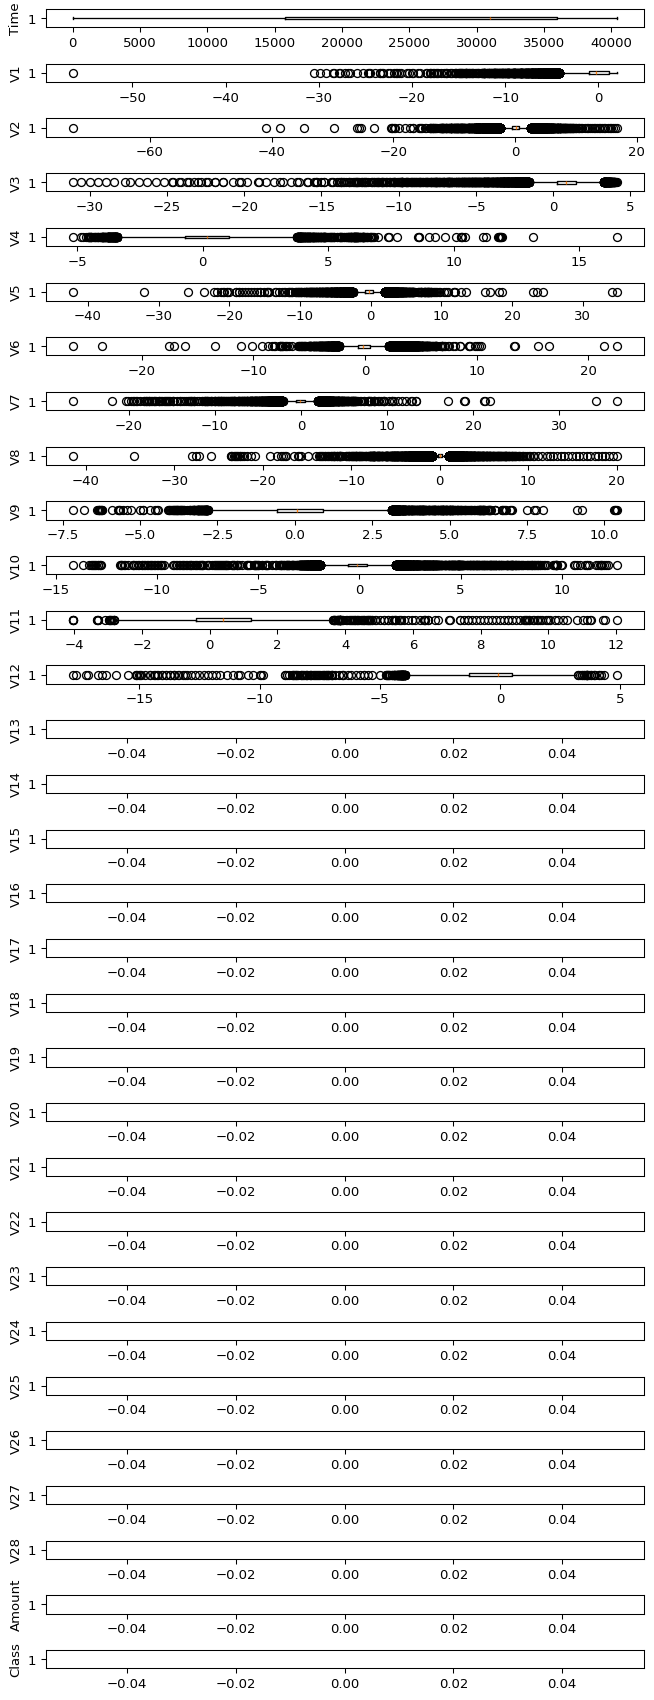

Outliers for column 'Time':


,Time


Outliers for column 'V1':


,V1
18,-5.401258
85,-4.575093
139,-4.257597
140,-5.101877
146,-5.285971
...,...
40700,-9.806380
40728,-6.207670
40730,-4.174871
40745,-5.977588


Outliers for column 'V2':


...

,V28
4,0.215153
7,-1.085339
18,0.949594
23,0.250475
25,0.243232
...,...
40751,-0.199327
40753,0.548388
40754,0.290072
40757,-0.176969


Outliers for column 'Amount':


,Amount
2,378.66
20,231.71
51,1402.95
64,243.66
85,200.01
...,...
40743,190.99
40745,359.78
40749,189.00
40763,333.23


Outliers for column 'Class':


,Class
541,1.0
623,1.0
4920,1.0
6108,1.0
6329,1.0
...,...
31002,1.0
33276,1.0
39183,1.0
40085,1.0


In [ ]:
# Visualise outliers
df_new.describe()

fig,axs=plt.subplots(len(df.columns),1,figsize=(7,18),dpi=95)
for i, col in enumerate(df.columns):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

# Calculate and print outliers for each column
for col in df.columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df_new[(df_new[col] < lower_bound) | (df_new[col] > upper_bound)]
  print(f"Outliers for column '{col}':")
  display(outliers[[col]])